In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from sklearn.preprocessing import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
movies=pd.read_csv("C:\\Users\\Admin\\ml project 1\\Project - Real_Time_Prediction_Model\\data\\movies.csv")
ratings=pd.read_csv("C:\\Users\\Admin\\ml project 1\\Project - Real_Time_Prediction_Model\\data\\ratings.csv")


In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [5]:
movies.shape

(62423, 3)

In [6]:
ratings.shape

(25000095, 4)

In [6]:
movies.info()
movies.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


movieId    0
title      0
genres     0
dtype: int64

In [7]:
ratings.info()
ratings.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

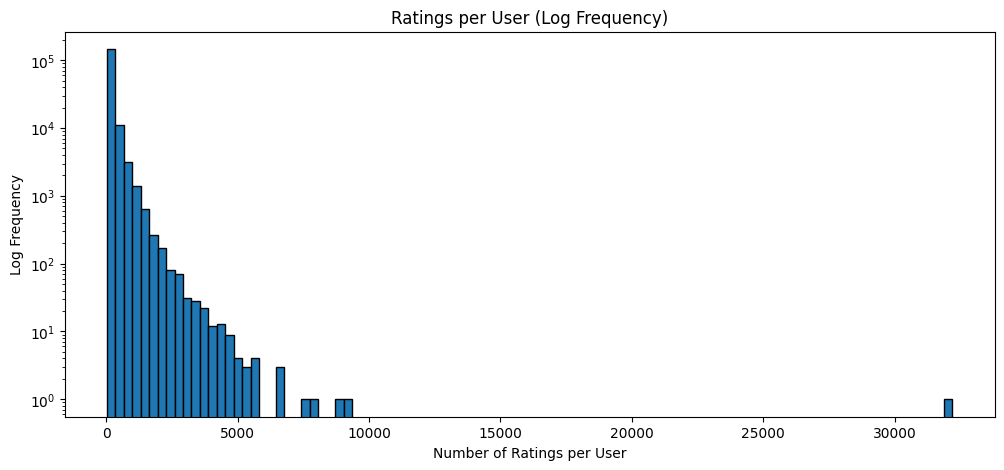

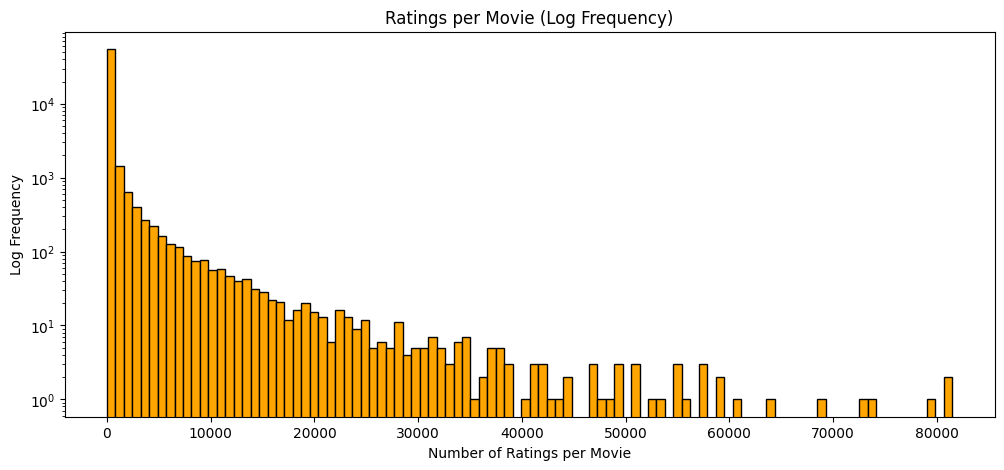

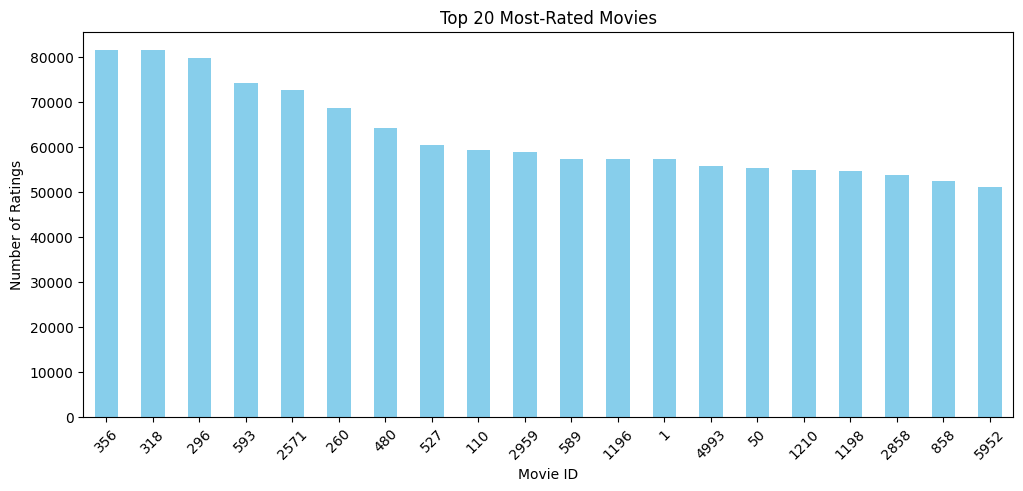

<Figure size 640x480 with 0 Axes>

User ratings stats:
count    162541.000000
mean        153.807932
std         268.047590
min          20.000000
25%          36.000000
50%          71.000000
75%         162.000000
max       32202.000000
Name: rating, dtype: float64

Movie ratings stats:
count    59047.000000
mean       423.393144
std       2477.885821
min          1.000000
25%          2.000000
50%          6.000000
75%         36.000000
max      81491.000000
Name: rating, dtype: float64


In [5]:
# User ratings distribution
ratings_per_user = ratings.groupby('userId')['rating'].size()
plt.figure(figsize=(12,5))
plt.hist(ratings_per_user, bins=100, edgecolor='black')
plt.yscale('log')
plt.title('Ratings per User (Log Frequency)')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Log Frequency')
plt.show()

ratings_per_movie = ratings.groupby('movieId')['rating'].size()
plt.figure(figsize=(12,5))
plt.hist(ratings_per_movie, bins=100, edgecolor='black', color='orange')
plt.yscale('log')
plt.title('Ratings per Movie (Log Frequency)')
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Log Frequency')
plt.show()

# Top 20 most-rated movies
top20_movies = ratings_per_movie.sort_values(ascending=False).head(20)
plt.figure(figsize=(12,5))
top20_movies.plot(kind='bar', color='skyblue')
plt.title('Top 20 Most-Rated Movies')
plt.xlabel('Movie ID')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45)
plt.show()
plt.tight_layout()
plt.show()

# Summary statistics
print(f"User ratings stats:\n{ratings_per_user.describe()}")
print(f"\nMovie ratings stats:\n{ratings_per_movie.describe()}")

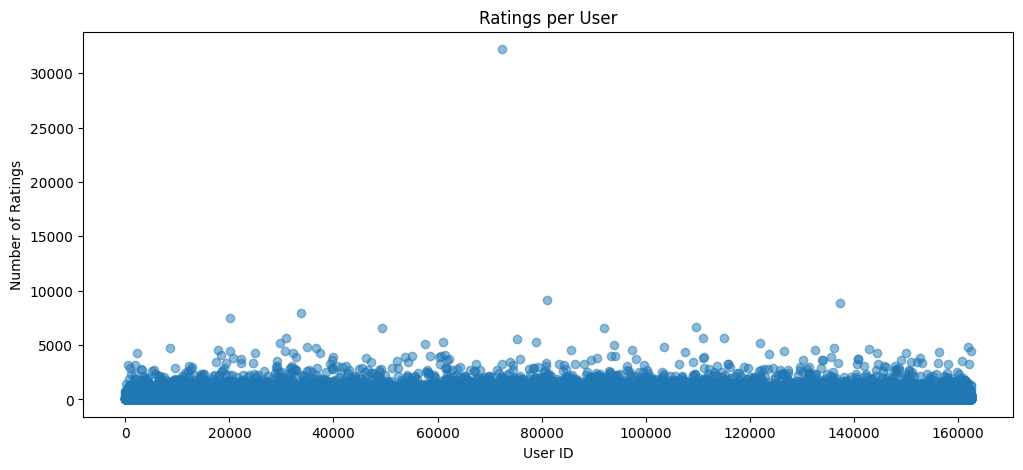

In [9]:
ratings_per_user = ratings.groupby('userId')['rating'].count()
plt.figure(figsize=(12,5))
plt.scatter(ratings_per_user.index, ratings_per_user.values, alpha=0.5)
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.title('Ratings per User')
plt.show()

In [12]:
# Count users with <5 ratings
cold_users = (ratings_per_user < 5).sum()
print(f"Users with <5 ratings: {cold_users}")

# Count movies with <5 ratings
cold_movies = (ratings_per_movie < 5).sum()
print(f"Movies with <5 ratings: {cold_movies}")

# Filter them out if needed
filtered_ratings = ratings.groupby('userId').filter(lambda x: len(x) >= 5)
filtered_ratings = filtered_ratings.groupby('movieId').filter(lambda x: len(x) >= 5)
print(f"Ratings after filtering: {len(filtered_ratings)}")

Users with <5 ratings: 7203
Movies with <5 ratings: 26327
Ratings after filtering: 24945870


In [13]:
# Sort ratings by timestamp per user
ratings_sorted = ratings.sort_values(['userId', 'timestamp'])

# Create train/test split (80/20 chronologically per user)
def train_test_split_by_time(df, test_size=0.2):
    train_list, test_list = [], []
    
    for user_id, group in df.groupby('userId'):
        n_ratings = len(group)
        n_test = int(n_ratings * test_size)
        
        if n_test > 0:
            train = group.iloc[:-n_test]
            test = group.iloc[-n_test:]
        else:
            train = group
            test = pd.DataFrame(columns=df.columns)
        
        train_list.append(train)
        test_list.append(test)
    
    train_df = pd.concat(train_list, ignore_index=True)
    test_df = pd.concat(test_list, ignore_index=True)
    
    return train_df, test_df

train_ratings, test_ratings = train_test_split_by_time(ratings_sorted, test_size=0.2)

print(f"Training set: {len(train_ratings)} ratings")
print(f"Test set: {len(test_ratings)} ratings")
print(f"Split ratio: {len(test_ratings)/(len(train_ratings)+len(test_ratings)):.2%}")

Training set: 20062533 ratings
Test set: 4937562 ratings
Split ratio: 19.75%
